# Notebook 03 — VIX Term Structure under Rough Heston

Computes the model VIX, variance swap rates, and VIX futures curve from
calibrated Rough Heston parameters. Compares against 4 historical CBOE dates.

**Runtime estimate:** 5–10 min (ODE integration + yfinance)

In [1]:
import os, sys
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "src") if os.path.basename(os.getcwd()) == "notebooks"
                else os.path.join(os.getcwd(), "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "font.family": "serif",
})
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

from market.vix_pricing import (
    model_vix, vix_futures_curve, model_variance_swap_rate, download_vix_futures
)
from market.variance_swaps import variance_swap_rate, variance_term_structure
from market.vix_futures import fetch_vix_futures


Device: cuda


## 1. VIX vs Initial Variance v₀

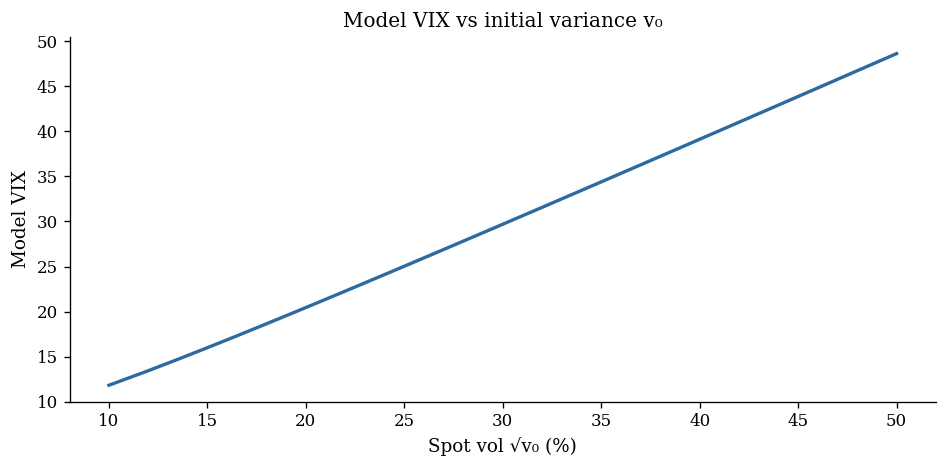

In [2]:
base = dict(kappa=1.5, theta=0.08, sigma=0.8, rho=-0.34, H=0.08)
v0_range = np.linspace(0.01, 0.25, 60)
vix_vals = [model_vix(**base, v0=v0, t=1/12) for v0 in v0_range]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.sqrt(v0_range)*100, vix_vals, color="#2d6a9f", lw=2)
ax.set_xlabel("Spot vol √v₀ (%)")
ax.set_ylabel("Model VIX")
ax.set_title("Model VIX vs initial variance v₀")
plt.tight_layout(); plt.show()


## 2. Variance Swap Term Structure

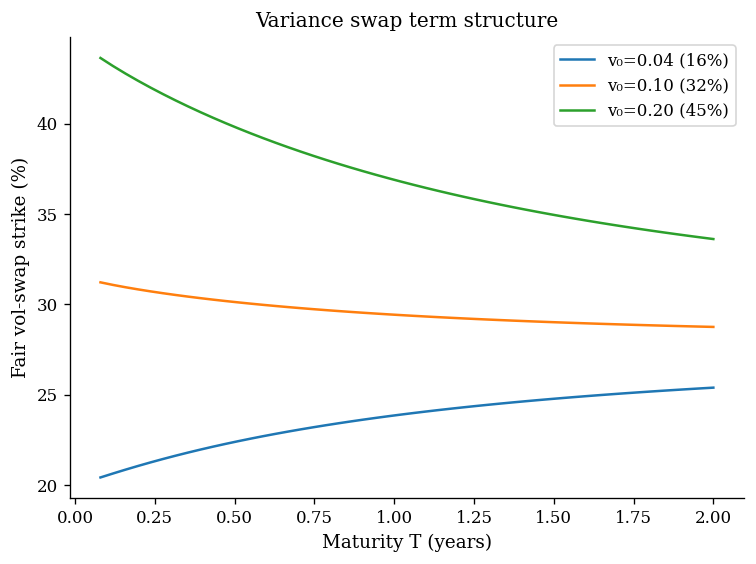

In [3]:
T_range = np.linspace(0.08, 2.0, 50)
for v0, label in [(0.04, "v₀=0.04 (16%)"), (0.10, "v₀=0.10 (32%)"), (0.20, "v₀=0.20 (45%)")]:
    rates = [model_variance_swap_rate(**base, v0=v0, T=T) for T in T_range]
    plt.plot(T_range, np.sqrt(rates)*100, label=label)
plt.xlabel("Maturity T (years)"); plt.ylabel("Fair vol-swap strike (%)")
plt.title("Variance swap term structure"); plt.legend(); plt.tight_layout(); plt.show()


## 3. Contango vs Backwardation

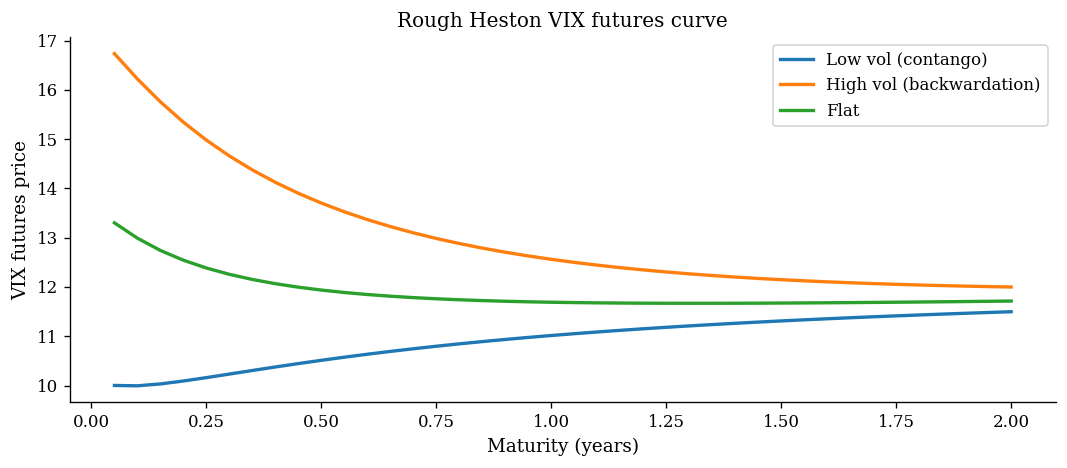

In [4]:
maturities = np.linspace(0.05, 2.0, 40)
scenarios = [
    dict(kappa=1.5, theta=0.08, sigma=0.8, rho=-0.34, v0=0.04, H=0.08, label="Low vol (contango)"),
    dict(kappa=1.5, theta=0.08, sigma=0.8, rho=-0.34, v0=0.18, H=0.08, label="High vol (backwardation)"),
    dict(kappa=1.5, theta=0.08, sigma=0.8, rho=-0.34, v0=0.10, H=0.08, label="Flat"),
]
fig, ax = plt.subplots(figsize=(9, 4))
for sc in scenarios:
    label = sc.pop("label")
    curve = vix_futures_curve(**sc, maturities=maturities)
    ax.plot(maturities, curve, lw=2, label=label)
    sc["label"] = label
ax.set_xlabel("Maturity (years)"); ax.set_ylabel("VIX futures price")
ax.set_title("Rough Heston VIX futures curve"); ax.legend(); plt.tight_layout(); plt.show()


## 4. Model vs Historical CBOE VIX Futures

Loads saved calibration results for 4 stress dates and plots model vs market.

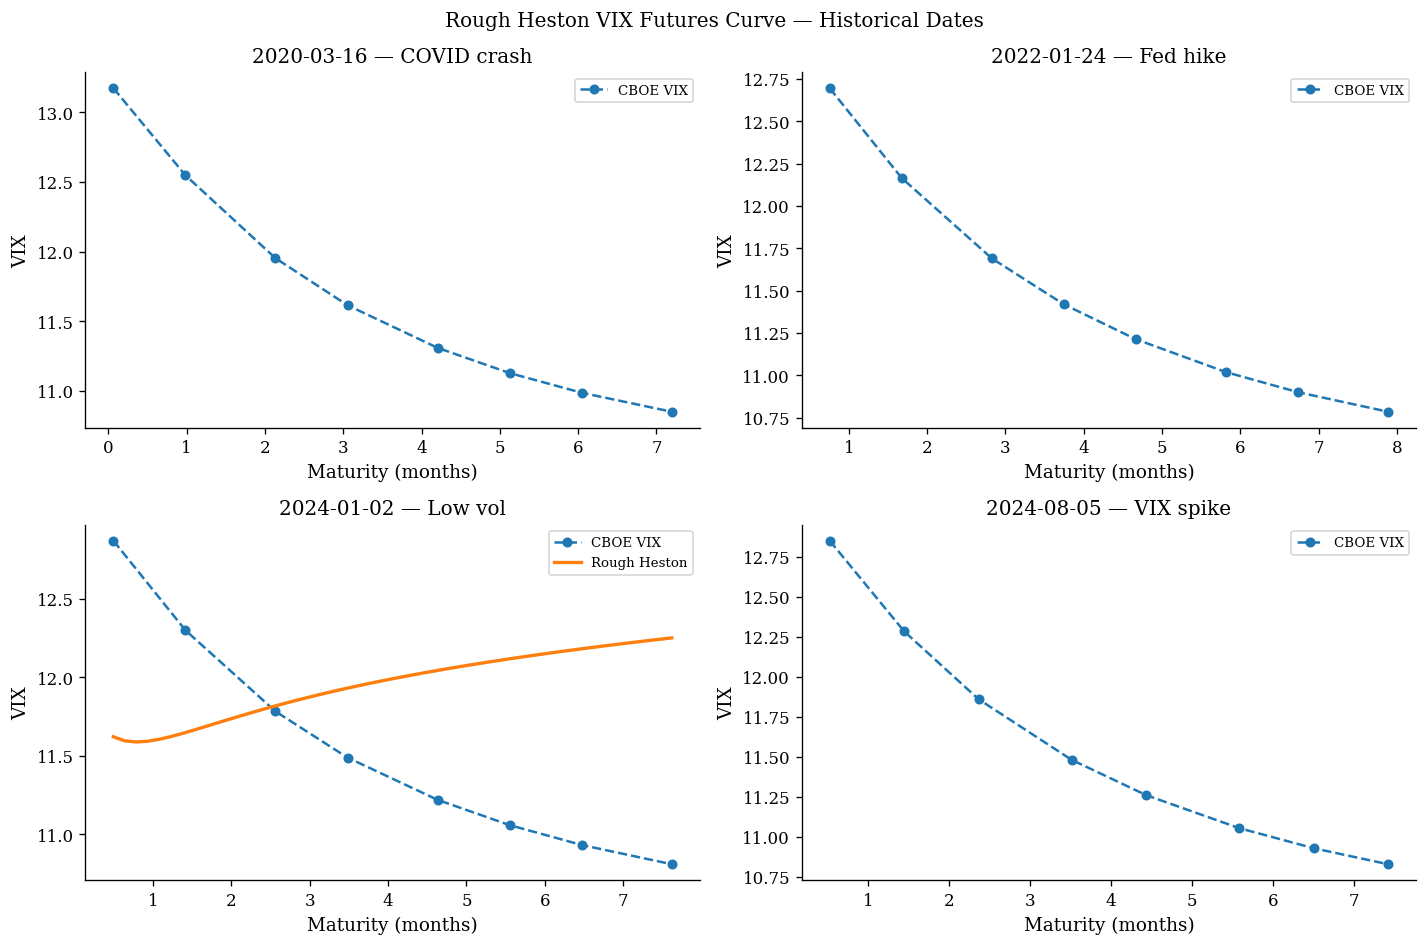

In [5]:
import json
dates_info = [
    ("2020-03-16", "COVID crash"),
    ("2022-01-24", "Fed hike"),
    ("2024-01-02", "Low vol"),
    ("2024-08-05", "VIX spike"),
]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (date_str, title) in zip(axes.flat, dates_info):
    vix_path   = f"../results/vix_term_structure/{date_str}.json"
    calib_path = f"../results/spx_calibration/{date_str}.json"
    if not os.path.exists(vix_path):
        ax.set_title(f"{date_str} — no data"); continue
    vix_list = json.load(open(vix_path))
    t_mkt = np.array([r["tenor_months"] for r in vix_list])
    v_mkt = np.array([r["settle_vix"]   for r in vix_list])
    ax.plot(t_mkt, v_mkt, "o--", ms=5, label="CBOE VIX")
    if os.path.exists(calib_path):
        cal = json.load(open(calib_path))
        p = cal.get("params", {})
        if all(k in p for k in ["kappa","theta","sigma","rho","v0","H"]):
            mats = np.linspace(t_mkt.min(), t_mkt.max(), 50)
            curve = vix_futures_curve(**p, maturities=mats)
            ax.plot(mats, curve, "-", lw=2, label="Rough Heston")
    ax.set_title(f"{date_str} — {title}"); ax.set_xlabel("Maturity (months)")
    ax.set_ylabel("VIX"); ax.legend(fontsize=8)
plt.suptitle("Rough Heston VIX Futures Curve — Historical Dates")
plt.tight_layout(); plt.show()


## 5. Hurst Exponent Sensitivity

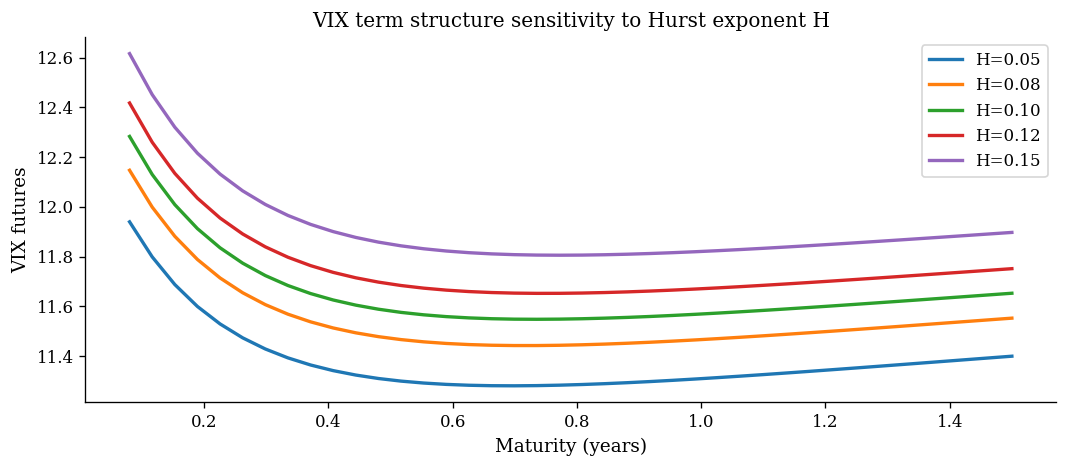

In [6]:
H_vals = [0.05, 0.08, 0.10, 0.12, 0.15]
mats   = np.linspace(0.08, 1.5, 40)
base   = dict(kappa=1.5, theta=0.08, sigma=0.8, rho=-0.34, v0=0.08)
fig, ax = plt.subplots(figsize=(9, 4))
for H in H_vals:
    curve = vix_futures_curve(**base, H=H, maturities=mats)
    ax.plot(mats, curve, lw=2, label=f"H={H:.2f}")
ax.set_xlabel("Maturity (years)"); ax.set_ylabel("VIX futures")
ax.set_title("VIX term structure sensitivity to Hurst exponent H")
ax.legend(); plt.tight_layout(); plt.show()
